In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# przełączyć, jeśli nie działa
# from bitalg.visualizer.main import Visualizer
from visualizer.main import Visualizer

In [2]:
def draw_mesh(vertices, triangles):
    vis = Visualizer()
    line_segments = []

    for a, b, c in triangles:
        line_segments.append((vertices[a], vertices[b]))
        line_segments.append((vertices[b], vertices[c]))
        line_segments.append((vertices[c], vertices[a]))

    vis.add_line_segment(line_segments)
    vis.add_point(vertices, color='red')
    
    vis.show()

In [3]:
# Wierzchołki (x, y) — indeksy 0..6
points = [
    (0.0, 0.0),  # 0
    (1.0, 0.0),  # 1
    (2.0, 0.0),  # 2
    (0.0, 1.0),  # 3
    (1.0, 1.0),  # 4
    (2.0, 1.0),  # 5
    (1.0, 2.0),  # 6
]

# Trójkąty (a, b, c) — indeksy wierzchołków, CCW
triangles = [
    (0, 1, 4),
    (0, 4, 3),
    (1, 2, 5),
    (1, 5, 4),
    (3, 4, 6),
    (4, 5, 6),
]

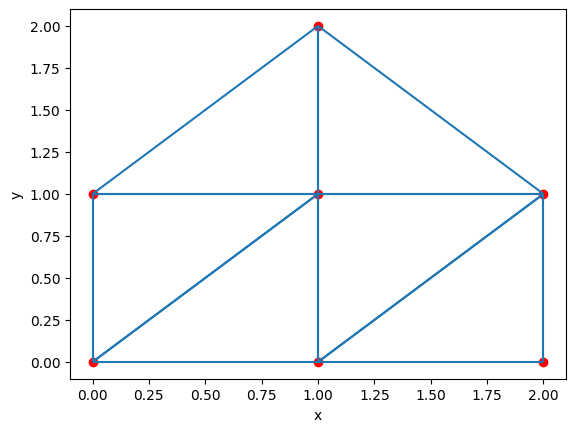

In [4]:
draw_mesh(points, triangles)

In [5]:
def load_mesh(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        n = int(f.readline().strip())
        m = int(f.readline().strip())

        points = []
        for _ in range(n):
            x, y = f.readline().split()
            points.append((float(x), float(y)))

        indices = []
        for _ in range(m):
            a, b, c = f.readline().split()
            indices.append((int(a), int(b), int(c)))

    return points, indices


In [6]:
points_siatka, triangles_siatka = load_mesh("siatka.txt")

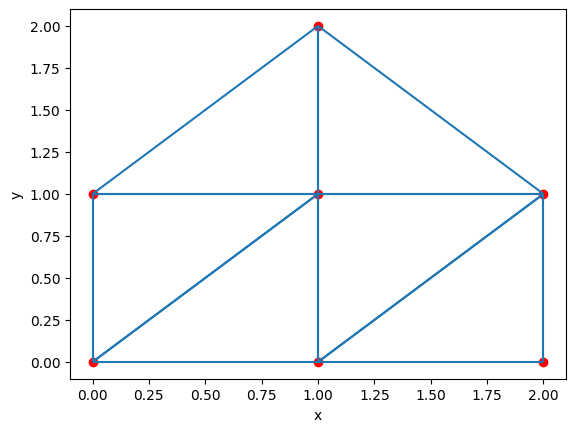

In [7]:
draw_mesh(points_siatka, triangles_siatka)

In [8]:
class HalfEdge:
    def __init__(self, origin=None, face=None, twin=None, next=None, prev=None):
        # origin: Vertex
        self.origin = origin

        # face: Face | None
        self.face = face

        # twin: HalfEdge | None
        self.twin = twin

        # next/prev: HalfEdge
        self.next = next
        self.prev = prev

In [15]:
class Vertex:
    def __init__(self, position, halfedge=None, id=None):
        # position: (float, float)
        self.position = position

        # halfedge: dowolna półkrawędź wychodząca z tego wierzchołka
        self.halfedge = halfedge

        # id: indeks wierzchołka
        self.id = id

    def __add__(self, other):
        return (self.position[0] + other.position[0], self.position[1] + other.position[1])

    def __sub__(self, other):
        return (self.position[0] - other.position[0], self.position[1] - other.position[1])

    def __mul__(self, num):
        return (self.position[0] * num, self.position[1] * num)

In [10]:
class Face:
    def __init__(self, halfedge=None):
        # halfedge: dowolna półkrawędź należąca do tej ściany (trójkąta)
        self.halfedge = halfedge

In [11]:
class HalfEdgeDataStructure:
    def __init__(self, points, triangles):
        self.vertices = [Vertex(pos, id=i) for i, pos in enumerate(points)]
        self.triangles = list(triangles)

        self.faces = []
        self.half_edges = []
        self.half_edges_dict = {}  # (u, v) -> HalfEdge u->v

        self._build_structure()
        self._build_boundary()

    def _pair_halfedge(self, u, v, edge):
        # szukamy przeciwnej półkrawędzi v->u
        t = self.half_edges_dict.get((v, u))
        if t is not None:
            edge.twin = t
            t.twin = edge
            del self.half_edges_dict[(v, u)]
        else:
            self.half_edges_dict[(u, v)] = edge

    def _build_structure(self):
        for a, b, c in self.triangles:
            face = Face()

            edge_0 = HalfEdge(origin=self.vertices[a], face=face)
            edge_1 = HalfEdge(origin=self.vertices[b], face=face)
            edge_2 = HalfEdge(origin=self.vertices[c], face=face)

            edge_0.next, edge_1.next, edge_2.next = edge_1, edge_2, edge_0
            edge_0.prev, edge_1.prev, edge_2.prev = edge_2, edge_0, edge_1

            face.halfedge = edge_0

            if self.vertices[a].halfedge is None:
                self.vertices[a].halfedge = edge_0
            if self.vertices[b].halfedge is None:
                self.vertices[b].halfedge = edge_1
            if self.vertices[c].halfedge is None:
                self.vertices[c].halfedge = edge_2

            # łączenie bliźniaczych krawędzi/dodawanie krawędzi do mapy
            self._pair_halfedge(a, b, edge_0)
            self._pair_halfedge(b, c, edge_1)
            self._pair_halfedge(c, a, edge_2)

            self.faces.append(face)
            self.half_edges.extend([edge_0, edge_1, edge_2])

    def _build_boundary(self):
        twinless_half_edges = list(self.half_edges_dict.values())

        new_boundary = []
        # tworzenie krawędzi na brzegach i łączenie ich z bliźniaczymi
        for edge in twinless_half_edges:
            u = edge.origin.id
            v = edge.next.origin.id

            b = HalfEdge(origin=self.vertices[v], face = None)
            b.twin = edge
            edge.twin = b

            new_boundary.append(b)

        # stworzenie mapy kolejnych połączeń dla krawędzi zewnętrznych
        incoming = {}
        for edge in twinless_half_edges:
            v = edge.next.origin.id
            incoming[v] = edge

        # łączenie następnych krawędzi zewnętrznych w pętlę
        for edge in twinless_half_edges:
            b = edge.twin
            u = edge.origin.id
            prev = incoming.get(u)
            b_next = prev.twin
            b.next = b_next
            b_next.prev = b

        self.half_edges.extend(new_boundary)

In [12]:
halfEdgeStructure = HalfEdgeDataStructure(points, triangles)

In [13]:
import math

def visualize_halfedge_structure(mesh,
                                 draw_mesh_edges=True,
                                 draw_vertices=True,
                                 shrink=0.15,
                                 inward_offset=0.05):
    vis = Visualizer()

    def add(a, b): return (a[0] + b[0], a[1] + b[1])
    def sub(a, b): return (a[0] - b[0], a[1] - b[1])
    def mul(a, s): return (a[0] * s, a[1] * s)
    def dot(a, b): return a[0] * b[0] + a[1] * b[1]
    def length(v): return math.hypot(v[0], v[1])
    def norm(v):
        l = length(v)
        return (0.0, 0.0) if l == 0 else (v[0] / l, v[1] / l)

    # krawędzie triangulacji
    if draw_mesh_edges:
        verts_pos = [v.position for v in mesh.vertices]
        mesh_segments = []
        for a, b, c in mesh.triangles:
            mesh_segments.append((verts_pos[a], verts_pos[b]))
            mesh_segments.append((verts_pos[b], verts_pos[c]))
            mesh_segments.append((verts_pos[c], verts_pos[a]))
        vis.add_line_segment(mesh_segments)

    # wierzchołki
    if draw_vertices:
        vis.add_point([v.position for v in mesh.vertices], color='red')

    internal_segments, internal_tips = [], []
    boundary_segments, boundary_tips = [], []

    for he in mesh.half_edges:
        if he.next is None or he.origin is None:
            continue

        p0 = he.origin.position
        p1v = he.next.origin
        if p1v is None:
            continue
        p1 = p1v.position

        v = sub(p1, p0)
        L = length(v)
        if L == 0:
            continue

        # skrócenie odcinka
        start = add(p0, mul(v, shrink))
        end   = add(p0, mul(v, 1.0 - shrink))

        if he.face is None:
            # boundary: nie przesuwamy do wnętrza (bo nie ma ściany)
            boundary_segments.append((start, end))
            boundary_tips.append(end)
            continue

        # internal: przesuwamy do wnętrza trójkąta
        if he.prev is None:
            continue

        pa = he.origin.position
        pb = he.next.origin.position
        pc = he.prev.origin.position
        centroid = ((pa[0] + pb[0] + pc[0]) / 3.0, (pa[1] + pb[1] + pc[1]) / 3.0)

        n = norm((-v[1], v[0]))
        mid = ((p0[0] + p1[0]) / 2.0, (p0[1] + p1[1]) / 2.0)
        if dot(n, sub(centroid, mid)) < 0:
            n = (-n[0], -n[1])

        offset = inward_offset * L
        start_i = add(start, mul(n, offset))
        end_i   = add(end,   mul(n, offset))

        internal_segments.append((start_i, end_i))
        internal_tips.append(end_i)

    vis.add_line_segment(internal_segments)
    vis.add_point(internal_tips, color='blue')

    # boundary wyróżniamy kolorem końcówek
    vis.add_line_segment(boundary_segments)
    vis.add_point(boundary_tips, color='green')

    vis.show()


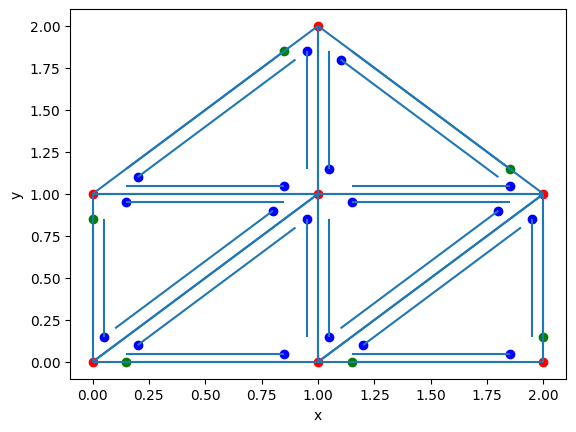

In [14]:
visualize_halfedge_structure(halfEdgeStructure)

# Operacje na siatce trójkątnej
### 1. Wyznaczanie otoczenia dla wybranego wierzchołka
### 2. Wyznaczanie otoczenia dla wybranego trójkąta
### 3. Przeglądanie incydentnych trójkątów od wybranego trójkąta w kierunku wybranego punktu

In [ ]:
def find_surrounding_point_list(vertex: Vertex):
    return